Youssef Mohamed Azmy

211004285

#                                                                                                      Quiz UNET

requirment 4 at the end


In [4]:
!mkdir ~/.kaggle
from google.colab import files
files.upload()  # select kaggle.json
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


mkdir: cannot create directory ‘/root/.kaggle’: File exists


Saving kaggle.json to kaggle.json


In [5]:
!kaggle datasets list


ref                                                               title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
wardabilal/spotify-global-music-dataset-20092025                  Spotify Global Music Dataset (2009–2025)               1289021  2025-11-11 09:43:05.933000           9654        219  1.0              
rohiteng/amazon-sales-dataset                                     Amazon Sales Dataset                                   4037578  2025-11-23 14:29:37.973000           2625         35  1.0              
sadiajavedd/students-academic-performance-dataset                 Students_Academic_Performance_Dataset                     8907  2025-10-23 04:16:35.563000          14597        346  1.0     

In [6]:
!kaggle datasets download -d nikhilroxtomar/brain-tumor-segmentation
!unzip -q brain-tumor-segmentation.zip


Dataset URL: https://www.kaggle.com/datasets/nikhilroxtomar/brain-tumor-segmentation
License(s): unknown
brain-tumor-segmentation.zip: Skipping, found more recently modified local copy (use --force to force download)
replace images/1.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace images/10.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace images/100.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
y


In [7]:
import os
import numpy as np
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

IMG_SIZE = 128
IMAGE_DIR = "/content/images"
MASK_DIR = "/content/masks"


In [8]:
def load_image(path):
    img = Image.open(path).convert("RGB")
    img = img.resize((IMG_SIZE, IMG_SIZE))
    return np.array(img) / 255.0


In [9]:
def load_mask(path):
    mask = Image.open(path).convert("L")
    mask = mask.resize((IMG_SIZE, IMG_SIZE))
    mask = np.array(mask)
    mask = (mask > 128).astype(np.float32)

    return np.expand_dims(mask, axis=-1)


In [10]:
def load_dataset(image_dir, mask_dir):
    images = []
    masks = []

    for fname in os.listdir(image_dir):
        if fname.endswith(".png"):
            img_path = os.path.join(image_dir, fname)
            mask_path = os.path.join(mask_dir, fname)

            if os.path.exists(mask_path):
                images.append(load_image(img_path))
                masks.append(load_mask(mask_path))

    return np.array(images, dtype=np.float32), np.array(masks, dtype=np.float32)

X, Y = load_dataset(IMAGE_DIR, MASK_DIR)
print("Dataset Loaded:", X.shape, Y.shape)


Dataset Loaded: (3064, 128, 128, 3) (3064, 128, 128, 1)


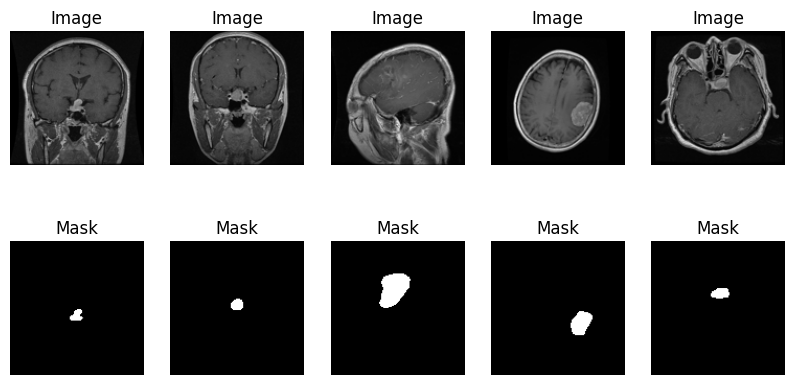

In [11]:
plt.figure(figsize=(10,5))
for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(X[i])
    plt.title("Image")
    plt.axis("off")

    plt.subplot(2,5,i+6)
    plt.imshow(Y[i].squeeze(), cmap="gray")
    plt.title("Mask")
    plt.axis("off")

plt.show()


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)


In [13]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train, Y_train)).batch(16).shuffle(200)
test_ds  = tf.data.Dataset.from_tensor_slices((X_test, Y_test)).batch(16)


In [14]:
def iou_metric(y_true, y_pred):
    y_pred = tf.cast(y_pred > 0.5, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection

    return intersection / (union + 1e-7)


In [15]:
def conv_block(filters, x):
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    return x


In [16]:
def build_unet():
    inputs = layers.Input((IMG_SIZE, IMG_SIZE, 3))

    c1 = conv_block(64, inputs)
    p1 = layers.MaxPooling2D()(c1)

    c2 = conv_block(128, p1)
    p2 = layers.MaxPooling2D()(c2)

    c3 = conv_block(256, p2)
    p3 = layers.MaxPooling2D()(c3)

    c4 = conv_block(512, p3)
    p4 = layers.MaxPooling2D()(c4)

    bn = conv_block(1024, p4)

    u1 = layers.UpSampling2D()(bn)
    u1 = layers.concatenate([u1, c4])
    c5 = conv_block(512, u1)

    u2 = layers.UpSampling2D()(c5)
    u2 = layers.concatenate([u2, c3])
    c6 = conv_block(256, u2)

    u3 = layers.UpSampling2D()(c6)
    u3 = layers.concatenate([u3, c2])
    c7 = conv_block(128, u3)

    u4 = layers.UpSampling2D()(c7)
    u4 = layers.concatenate([u4, c1])
    c8 = conv_block(64, u4)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(c8)

    return keras.Model(inputs, outputs)


In [17]:
model = build_unet()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[iou_metric]
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 8, 8, 512) │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 8, 8,      │  4,719,616 │ max_pooling2d_3[… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 8, 8,      │  9,438,208 │ conv2d_8[0][0]    │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 16, 16,    │          0 │ conv2d_9[0][0]    │
│ (UpSampling2D)      │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ up_sampling2d[0]

 Total params: 31,378,945 (119.70 MB)

 Trainable params: 31,378,945 (119.70 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=12,
)


Epoch 1/12
154/154 ━━━━━━━━━━━━━━━━━━━━ 121s 511ms/step - iou_metric: 0.0018 - loss: 0.2215 - val_iou_metric: 0.0000e+00 - val_loss: 0.0659
Epoch 2/12
154/154 ━━━━━━━━━━━━━━━━━━━━ 38s 247ms/step - iou_metric: 0.0000e+00 - loss: 0.0604 - val_iou_metric: 0.0000e+00 - val_loss: 0.0549
Epoch 3/12
154/154 ━━━━━━━━━━━━━━━━━━━━ 38s 247ms/step - iou_metric: 0.0000e+00 - loss: 0.0547 - val_iou_metric: 0.0000e+00 - val_loss: 0.0479
Epoch 4/12
154/154 ━━━━━━━━━━━━━━━━━━━━ 38s 247ms/step - iou_metric: 0.0762 - loss: 0.0459 - val_iou_metric: 0.3512 - val_loss: 0.0378
Epoch 5/12
154/154 ━━━━━━━━━━━━━━━━━━━━ 38s 247ms/step - iou_metric: 0.3405 - loss: 0.0362 - val_iou_metric: 0.3686 - val_loss: 0.0356
Epoch 6/12
154/154 ━━━━━━━━━━━━━━━━━━━━ 38s 247ms/step - iou_metric: 0.4095 - loss: 0.0318 - val_iou_metric: 0.5016 - val_loss: 0.0275
Epoch 7/12
154/154 ━━━━━━━━━━━━━━━━━━━━ 38s 247ms/step - iou_metric: 0.4843 - loss: 0.0269 - val_iou_metric: 0.5220 - val_loss: 0.0269
Epoch 8/12
154/154 ━━━━━━━━━━━━━━━

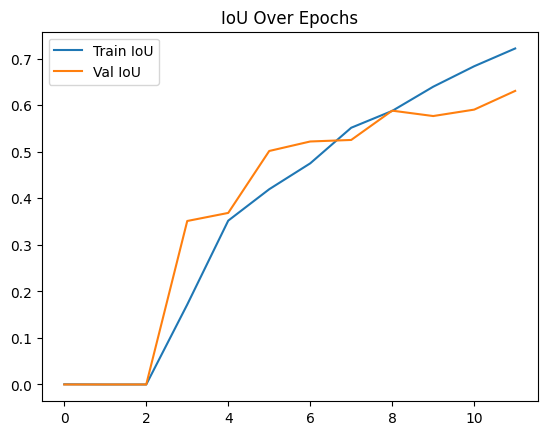

In [19]:
plt.plot(history.history["iou_metric"])
plt.plot(history.history["val_iou_metric"])
plt.title("IoU Over Epochs")
plt.legend(["Train IoU", "Val IoU"])
plt.show()


20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 151ms/step


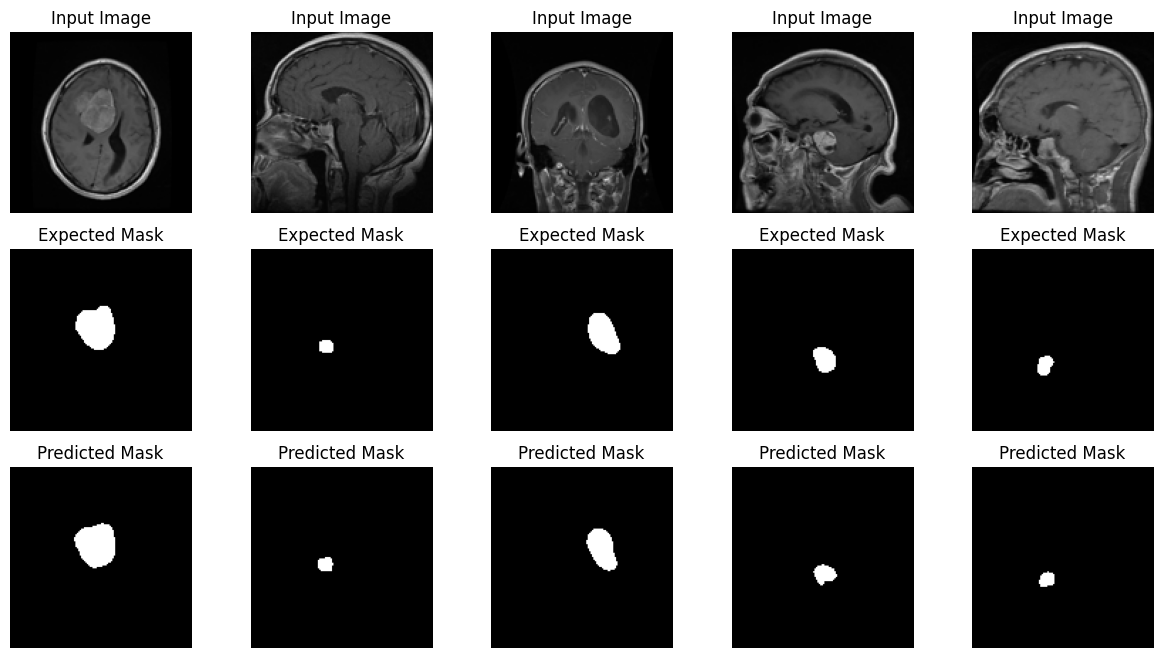

In [21]:
preds = model.predict(X_test)

preds_bin = (preds > 0.5).astype(np.float32)

plt.figure(figsize=(15,8))

for i in range(5):
    plt.subplot(3,5,i+1)
    plt.imshow(X_test[i])
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(3,5,i+6)
    plt.imshow(Y_test[i].squeeze(), cmap="gray")
    plt.title("Expected Mask")
    plt.axis("off")

    plt.subplot(3,5,i+11)
    plt.imshow(preds_bin[i].squeeze(), cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

plt.show()


4- Write definition of IoU and why is it used for evaluating semantic segmentation models instead of accuracy.


# **IoU=Union Area / Overlap Area​**

Intersection over Union, or IoU, is a metric that evaluates how well a segmentation model identifies the correct region in an image. It works by comparing the predicted mask to the real mask and checking how much they overlap. Because it divides the overlap by the total area covered by both masks, IoU gives a fair and balanced measure of how close the prediction is to the truth. IoU is preferred over accuracy in semantic segmentation because accuracy can be misleading in images where most pixels belong to the background. For example, in medical scans the tumor usually occupies a very small region, so a model could mark everything as background and still achieve high accuracy even though it fails completely at detecting the tumor. IoU avoids this problem by focusing only on the region of interest and measuring how well the predicted shape matches the true one, making it a much more meaningful and reliable evaluation metric.